# Epidemic Spreading in Hyperbolic Space (ES-HS)
TFG Adrià Rojo, 2026

## Parametres

In [3]:
n = 1000
g = 2.1
b = 2.1
k = 20

filename = f"n{n}-g={g}-b={b}"

if k:
    filename += f"-k={k}"

working_folder = f'./pipeline-output/out-{filename}'
coords_file = f"{working_folder}/{filename}.inf_coord"
edges_file = f"{working_folder}/{filename}.edge"
edges_GC_file = f"{working_folder}/{filename}_GC.edge"
file_without_ext = f"{working_folder}/{filename}"

! mkdir {working_folder} -p

## Eines

In [1]:
! mkdir tools -p

### Compilació

#### SD Model

In [5]:
! g++ -O3 -std=c++17 -lboost_system -lboost_math_c99 SD-model/src/generatingSD_unix.cpp -o tools/genSD

In file included from /usr/include/boost/math/quadrature/gauss.hpp:15,
                 from SD-model/src/../include/generatingSD.hpp:41,
                 from SD-model/src/../include/generatingSD_unix.hpp:33,
                 from SD-model/src/generatingSD_unix.cpp:30:
/usr/include/boost/math/special_functions/legendre.hpp: In instantiation of ‘std::pair<_FIter, _FIter> boost::math::detail::legendre_p_zero_func<T, Policy>::operator()(T) const [with T = double; Policy = boost::math::policies::policy<boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy>]’:
/usr/include/boost/math/tools/roots.hpp:281:29:   required from

#### Mercator

In [6]:
! g++ -O3 -std=c++11 -fpermissive -I ./mercator/include/ ./mercator/src/embeddingS1_unix.cpp -o ./tools/mercator


In file included from ./mercator/src/../include/Eigen/Core:467,
                 from ./mercator/src/../include/embeddingS1.hpp:52,
                 from ./mercator/src/../include/embeddingS1_unix.hpp:36,
                 from ./mercator/src/embeddingS1_unix.cpp:30:
./mercator/src/../include/Eigen/src/Core/Transpositions.h: In function ‘const Eigen::Product<OtherDerived, Eigen::Transpose<Eigen::TranspositionsBase<Derived> >, 2> Eigen::operator*(const MatrixBase<OtherDerived>&, const Transpose<TranspositionsBase<Derived> >&)’:
./mercator/src/../include/Eigen/src/Core/Transpositions.h:387:87: warning: ‘const class Eigen::Transpose<Eigen::TranspositionsBase<Derived> >’ has no member named ‘derived’ []8;;https://gcc.gnu.org/onlinedocs/gcc/C_002b_002b-Dialect-Options.html#index-Wno-template-body-Wtemplate-body]8;;]
  387 | Derived, Transpose, AliasFreeProduct>(matrix.derived(), trt.derived());
      |                                                             ^~~~~~~


#### Epidemics

In [90]:
! gfortran -O3 -march=native -funroll-loops -fopenmp -g \
    ./epidemics-tfg/include/mt19937.f90 ./epidemics-tfg/include/mt19937_par.f90 ./epidemics-tfg/include/fhash.f90 \
    ./epidemics-tfg/include/net_loader.f90 ./epidemics-tfg/include/reversed_skiplist.f90 ./epidemics-tfg/include/epidemic.f90 \
    ./epidemics-tfg/main2.f90 \
    -o ./tools/epidemics
! gfortran -O3 -march=native -funroll-loops -g \
    ./epidemics-tfg/include/mt19937.f90 ./epidemics-tfg/include/mt19937_par.f90 ./epidemics-tfg/include/fhash.f90 \
    ./epidemics-tfg/include/net_loader.f90 ./epidemics-tfg/include/reversed_skiplist.f90 ./epidemics-tfg/include/epidemic.f90 \
    ./epidemics-tfg/main2.f90 \
    -o ./tools/epidemics_debug
! rm ./*.mod

In [91]:
! ./tools/epidemics -h

SIMULADOR DE EPIDEMIAS EN REDES
Adrià Rojo

Uso: programa [OPCIONES] ARCHIVO_RED

ARGUMENTOS OBLIGATORIOS:
  ARCHIVO_RED                    Archivo de la red (formato compatible con net_loader)

OPCIONES:
  -h, --help                     Muestra esta ayuda

  -i, --infection-rate VALOR     Tasa de infección (obligatorio)
  -r, --recovery-rate VALOR      Tasa de recuperación (obligatorio)
  -m, --model {SIR,SIS}          Modelo epidémico (obligatorio)

  -lt, --limit-time VALOR        Tiempo máximo de simulación (default: 50.0)
  -s, --seed VALOR               Semilla para el generador aleatorio
  -sn, --start-node              Indica el nodo inicial para infectar
                                 (default: el nodo con degree más alto)
  -w, --weighted                 Indica que la red es ponderada
  -b, --batch-file ARCHIVO       Archivo con lista de simulaciones a ejecutar
                                 (cada línea: inf_rate rec_rate seed limit_time model [start_node])

ARCHIVOS DE S

### Generació de xarxes

In [ ]:
! ./tools/genSD -h

In [ ]:
! ./tools/mercator -h

In [16]:
import re
from pathlib import Path
! ./tools/genSD -d 1 -n {n} -g {g} -k {k} -b {b} -s 12345 -o {file_without_ext}
t = Path(edges_file).read_text()
t = re.sub(r'v(\d)', r'\1', t)
Path(edges_file).write_text(t)


OUTPUT_ROOTNAME = /home/adria/universitat/epidemics-tfg-pipeline/./pipeline-output/out-n1000-g=2.1-b=2.1-k=20/n1000-g=2.1-b=2.1-k=20
edgelist_file = /home/adria/universitat/epidemics-tfg-pipeline/./pipeline-output/out-n1000-g=2.1-b=2.1-k=20/n1000-g=2.1-b=2.1-k=20.edge


217777

In [17]:
! ./tools/mercator -o {file_without_ext} -b {b} -s 12345 {edges_file}
! ./tools/mercator -o {file_without_ext} -b {b} -s 12345 {edges_GC_file}

Could not open file: ./pipeline-output/out-n1000-g=2.1-b=2.1-k=20/n1000-g=2.1-b=2.1-k=20_GC.edge.
terminate called without an active exception


## Visualització

### Funcions

In [4]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import uncertainties as un
from pipeline.init import configure_matplotlib, ajuste_polinomial_con_estadisticas_v2

configure_matplotlib()

In [5]:
# arxiv 1v41801.4091
import pipeline.hyperbolic as hyp
import pipeline.figures as figs
import pipeline.data as data
import pipeline.boost as boost

### Càrrega inicial

In [6]:
G, df, params = data.read_hyperbolic_data(coords_file, edges_file)

# df[['Inf.Theta', 'Disc.Radius', 'x0', 'x1', 'x2', 'Verifi']]
df

,Vertex,Inf.Kappa,Inf.Theta,Inf.Hyp.Rad.,Disc.Radius,x0,x1,x2,Verifi,Disc.X,Disc.Y
0,0,26.27600,3.03249,15.2183,15.218314,-1.008673,0.131206,-0.014372,-1.0,-15.127829,1.657066
1,1,5.23699,1.69472,18.4441,18.444133,-1.005896,0.013443,-0.107921,-1.0,-2.279819,18.302690
2,2,1.24760,4.14545,21.3132,21.313183,-1.004413,0.050507,0.079332,-1.0,-11.446297,-17.978711
3,3,20.84740,2.83469,15.6812,15.681168,-1.008167,0.122078,-0.038689,-1.0,-14.948448,4.737398
4,4,8.72269,5.58489,17.4238,17.423771,-1.006610,-0.088209,0.074041,-1.0,13.345550,-11.201968
...,...,...,...,...,...,...,...,...,...,...,...
993,995,10.17020,5.89835,17.1167,17.116703,-1.006850,-0.108670,0.044015,-1.0,15.864792,-6.425721
994,996,8.11088,4.93800,17.5692,17.569214,-1.006500,-0.025548,0.111311,-1.0,3.930267,-17.123968
995,997,5.27762,1.41399,18.4287,18.428676,-1.005906,-0.016998,-0.107512,-1.0,2.877905,18.202576
996,998,12.31940,5.05495,16.7333,16.733276,-1.007168,-0.040291,0.112981,-1.0,5.620714,-15.761031


### Mapa

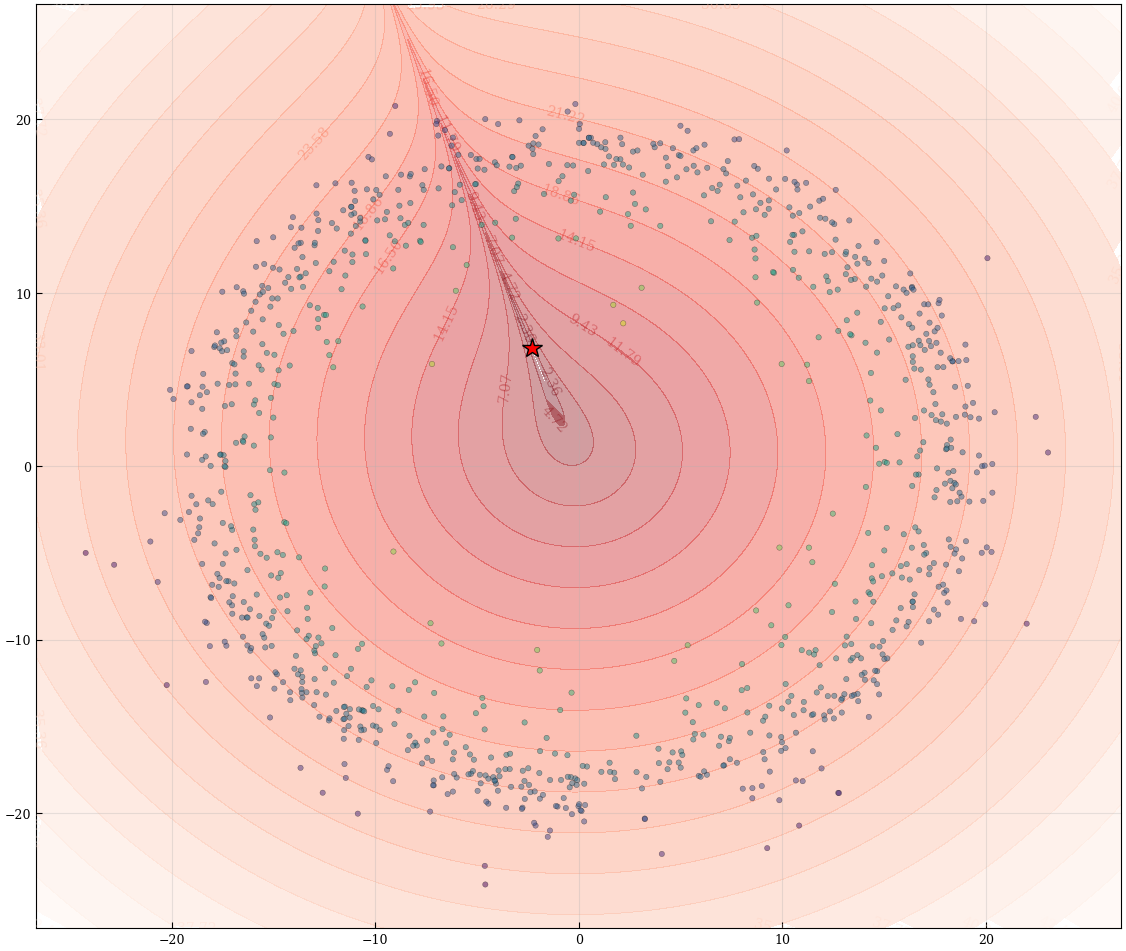

In [22]:
R = 2 * np.log(params['nb. vertices']/(params['mu']*np.pi*params['kappa_min']**2))
popular = data.get_most_popular_node(G)
figs.mercator_disc(df, title='', mark_nodes=[popular], isolines_nodes=[popular], R=R, c=-0.1)

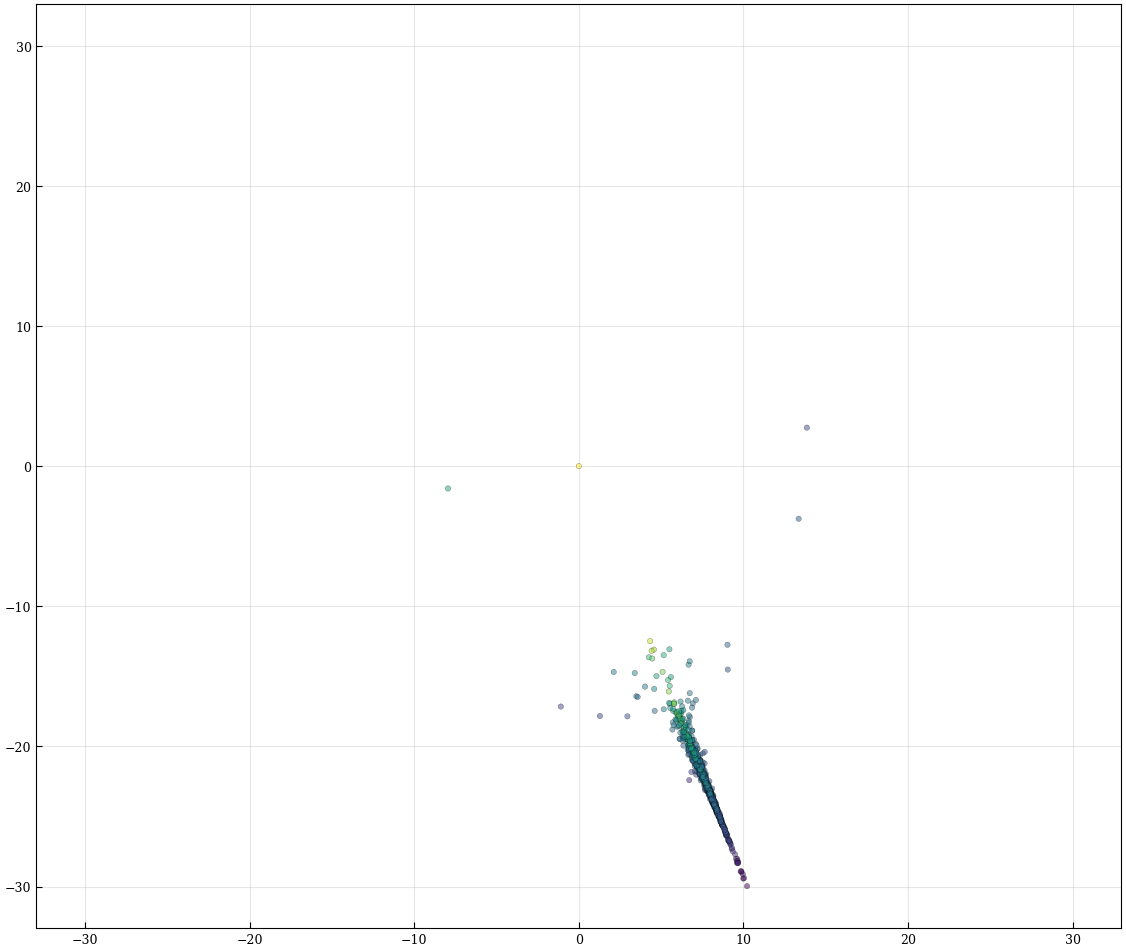

In [23]:
popular = data.get_most_popular_node(G)
selected = df[df['Vertex'] == popular].iloc[0]
r, theta = selected['Disc.Radius'], selected['Inf.Theta']
a=1
r_changed, theta_changed = boost.centrar_en_origen(df['Disc.Radius'], df['Inf.Theta'], r, theta)
df2 = pd.DataFrame()
df2['Vertex'] = df['Vertex']
df2['Inf.Kappa'] = df['Inf.Kappa']
df2['Disc.Radius'] = r_changed
df2['Inf.Theta'] = theta_changed
df2['Disc.X'] = df2['Disc.Radius']*np.cos(df2['Inf.Theta'])
df2['Disc.Y'] = df2['Disc.Radius']*np.sin(df2['Inf.Theta'])
figs.mercator_disc(df2)

### Epidèmia

In [8]:
params

{'Elapsed CPU time': '14.5891 seconds',
 'Edgelist file': './pipeline-output/out-n1000-g=2.1-b=2.1-k=35/n1000-g=2.1-b=2.1-k=35.edge',
 'nb. vertices': 1000.0,
 'beta': 2.1,
 'mu': 0.016751,
 'radius_S1': 159.155,
 'radius_H2': 19.0779,
 'kappa_min': 1.16963,
 'EDGELIST_FILENAME': './pipeline-output/out-n1000-g=2.1-b=2.1-k=35/n1000-g=2.1-b=2.1-k=35.edge',
 'ROOTNAME_OUTPUT': './pipeline-output/out-n1000-g=2.1-b=2.1-k=35/n1000-g=2.1-b=2.1-k=35'}

#### Arxius

In [26]:
R = 2 * np.log(params['nb. vertices']/(params['mu']*np.pi*params['kappa_min']**2))


edges = pd.DataFrame(G.edges, columns=['a', 'b'])
edges = pd.merge(edges, df[['Vertex', 'Disc.Radius', 'Inf.Theta']], left_on='a', right_on='Vertex', suffixes=('_a', '_b'))
edges = pd.merge(edges, df[['Vertex', 'Disc.Radius', 'Inf.Theta']], left_on='b', right_on='Vertex', suffixes=('_a', '_b'))
edges['Theta_Dif'] = np.pi - np.abs(np.pi - np.abs(edges['Inf.Theta_a']-edges['Inf.Theta_b']))

edges['Distance'] = np.where(edges['Theta_Dif'] == 0, 
                            np.abs(edges['Disc.Radius_a']- edges['Disc.Radius_b']), 
                            hyp.hyperbolic_distance_og(edges['Disc.Radius_a'], edges['Disc.Radius_b'], edges['Theta_Dif']))



for n in range(10):
    c = -(n+1)/10
    edges['Epidemic_Func'] = hyp.link_probability_og(edges['Distance'], R, c)

    avg_epidemic_func = np.average(edges['Epidemic_Func'])

    edges['Weight_Multiplier'] = edges['Epidemic_Func']/avg_epidemic_func
    edges.to_csv(f"{edges_file}_weight_-{n+1}x10^-1", sep='\t', header=False, index=False, columns=['a', 'b', 'Weight_Multiplier'])

#### Estadístiques

In [ ]:
output_batch_file = f"{working_folder}/batch_sir_evolution.txt"

infection_rates = (range(1, 51))      # 1..200
random_seeds = range(1, 61)       # 1..60

recovery_rate = 1E-1
limit_time = 1E10
model_type = 2   # SIR_MODEL
n = 0
start_node = 996
with open(output_batch_file, "w") as f:
    f.write("# infection_rate  recovery_rate  seed  limit_time  model_type start_node\n")
    for i in infection_rates:
        infection_rate = i * 2 / 100.0   # real(i_sim*2, dp)/100
        for j in random_seeds:
            seed = 42069 + j
            # Escribir línea con 5 valores (start_node opcional omitido)
            f.write(f"{infection_rate:.6f} {recovery_rate:.6f} {seed} {limit_time:.1f} {model_type} {start_node}\n")
            n = n+1

print(f"Archivo batch generado: {output_batch_file} con {n} simulaciones.")

Archivo batch generado: ./pipeline-output/out-n10000-g=2.2-b=3/batch_sir_evolution.txt con 3000 simulaciones.


In [ ]:
n = -1
origin = 996
folder = f'{working_folder}/weight_-10^{n}'
weights = f'{edges_file}_weight_-10^{n}'
! rm -rf {folder}
! mkdir {folder}
cmd = f"./tools/epidemics -b {output_batch_file} -o {folder} -ss 10000 -st -w -sn {origin} {weights}"
! {cmd}

In [ ]:
origin = 996
for n in range(10):
    folder = f'{working_folder}/weight_-{n+1}x10^-1'
    weights = f'{edges_file}_weight_-{n+1}x10^-1'
    ! rm -rf {folder}
    ! mkdir {folder}
    cmd = f"./tools/epidemics -b {output_batch_file} -o {folder} -ss 100000 -st -w -sn {origin} {weights}"
    ! {cmd}

In [ ]:
max_key = max(dict(G.degree()).items(), key=lambda x: x[1])[0]
display(max_key)

folder = f'{working_folder}/unweighted'
! rm -rf {folder}
! mkdir {folder}
! ./tools/epidemics -b {output_batch_file} -o {folder} -st -sn {max_key} {edges_file}

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from multiprocessing import Pool
import functools
import pipeline.process as process

if __name__ == "__main__":
    iters = range(2, 100+1, 2)
    dfs_weights = {}
    
    for weight in range(10):
    # for weight in [-1]:
        rates = np.multiply(iters, 0.01)
        # Usar partial para fijar el argumento weight
        process_func = functools.partial(process.process_rate, weight=weight+1, working_folder=working_folder)
        
        with Pool() as pool:
            results = list(tqdm(pool.imap(process_func, rates), 
                            total=len(iters)))
        
        dfs_weights['unweighted' if weight is None else f'weight_-{weight+1}x10^-1'] = pd.DataFrame(results)

  0%|          | 0/50 [00:00<?, ?it/s]

./pipeline-output/out-n10000-g=2.2-b=3/weight_-1x10^-1/stats-n10000-g=2.2-b=3_GC-wSIR-I=   0.14000-R=   0.10000-S=42111.dat
./pipeline-output/out-n10000-g=2.2-b=3/weight_-1x10^-1/stats-n10000-g=2.2-b=3_GC-wSIR-I=   0.34000-R=   0.10000-S=42088.dat./pipeline-output/out-n10000-g=2.2-b=3/weight_-1x10^-1/stats-n10000-g=2.2-b=3_GC-wSIR-I=   0.18000-R=   0.10000-S=42118.dat
./pipeline-output/out-n10000-g=2.2-b=3/weight_-1x10^-1/stats-n10000-g=2.2-b=3_GC-wSIR-I=   0.20000-R=   0.10000-S=42120.dat



  0%|          | 0/50 [00:00<?, ?it/s]

./pipeline-output/out-n10000-g=2.2-b=3/weight_-2x10^-1/stats-n10000-g=2.2-b=3_GC-wSIR-I=   0.12000-R=   0.10000-S=42109.dat
./pipeline-output/out-n10000-g=2.2-b=3/weight_-2x10^-1/stats-n10000-g=2.2-b=3_GC-wSIR-I=   0.26000-R=   0.10000-S=42078.dat
./pipeline-output/out-n10000-g=2.2-b=3/weight_-2x10^-1/stats-n10000-g=2.2-b=3_GC-wSIR-I=   0.26000-R=   0.10000-S=42098.dat
./pipeline-output/out-n10000-g=2.2-b=3/weight_-2x10^-1/stats-n10000-g=2.2-b=3_GC-wSIR-I=   0.48000-R=   0.10000-S=42102.dat


 68%|██████▊   | 34/50 [00:00<00:00, 322.35it/s]

./pipeline-output/out-n10000-g=2.2-b=3/weight_-2x10^-1/stats-n10000-g=2.2-b=3_GC-wSIR-I=   0.92000-R=   0.10000-S=42082.dat


100%|██████████| 50/50 [00:00<00:00, 445.97it/s]


In [ ]:
# set_gnuplot_style()
import itertools
marker = itertools.cycle((',', '+', '.', 'o', '*')) 
fig, ax = plt.subplots(figsize=(5,3), dpi=100)
ax.minorticks_on()
for weight in range(3):
# for weight in [-1]:
    df_outbreak = dfs_weights['unweighted' if weight is None else f'weight_-{weight+1}x10^-1']
    ax.scatter(df_outbreak['rate'], 
               df_outbreak['outbreak_size'],
               marker=next(marker),
               s=8,
               label=(f'$c={(weight+1)/10}$'))
# ax.errorbar(dfs['rate'], dfs['integral'], yerr=dfs['err_integral'], marker='o', linestyle='none')
# ax.scatter(df_data['x'], df_data['y'], marker='o')
ax.set_xlabel(r'$\lambda/\delta$')
ax.set_ylim(-0.01, 1.01)
ax.set_yticks([i*0.2 for i in range(6)])
ax.set_yticklabels([str(i*20) for i in range(6)])
ax.set_xlim(0, 10)
# ax.legend("Outbreak")
# ax.set_ylim(0)
ax.set_ylabel(r'Infected population (\%)')
ax.annotate(r'$f(x_{ij}-R) = e^{-c(x_{ij}-R)}$', (1, 0.4))
ax.legend()
ax.grid(alpha=0.3)
ax.set_title('Outbreak size')
fig.savefig('./figures/wSIR-outbreak-size.pdf')
plt.show()

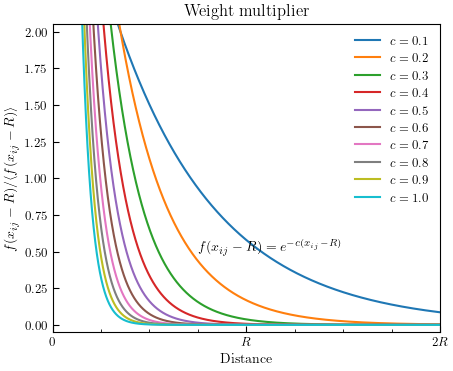

In [24]:
fig, ax = plt.subplots(figsize=(5,4),dpi=100)
R = 2 * np.log(params['nb. vertices']/(params['mu']*np.pi*params['kappa_min']**2))

ax.xaxis.set_minor_locator(MultipleLocator(R/4))
# ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.set_xticks(ticks=[0, R, 2*R], 
              labels=['$0$', '$R$', '$2R$'])
xs = np.linspace(0, 2*R, 100000)

for n in range(10):
    c = (n+1)/10
    prob = hyp.link_probability_og(xs, R, -c)
    avprob = np.average(prob)
    ax.plot(xs, prob/avprob, label=f'$c={{{c}}}$')
ax.legend()

ax.set_xlabel('Distance')
ax.set_ylabel(r'$f(x_{ij}-R)/\langle f(x_{ij}-R) \rangle$')
ax.set_xlim(0, 2*R)
ax.set_ylim(-0.05, 2.05)
ax.annotate(r"$f(x_{ij}-R) = {e^{-c(x_{ij}-R)}}$", (6*R/8, 0.5))
# ax.set_yscale('log')
# ax.grid(alpha=0.3, which='minor', axis='x')
# ax.grid(alpha=0.3, which='major')
ax.set_title('Weight multiplier')
fig.savefig('./figures/weight-multiplier.pdf')
plt.show()


#### GIF

In [10]:
from pathlib import Path
i_rate = 1
r_rate = 1
seed = 42075
model = 'SIR'
weighted = True
start_node = data.get_most_popular_node(G)
c = "-1x10^-1"
weight_file = f'{edges_file}_weight_{c}'
# weight_file = f'{edges_file}'
epidemic_folder = f'{working_folder}/epidemic_{c}'
expected_events_name = f'{epidemic_folder}/{data.build_events_filename(Path(edges_file).stem, weighted, model, i_rate, r_rate, seed)}'
expected_stats_name = f'{epidemic_folder}/{data.build_stats_filename(Path(edges_file).stem, weighted, model, i_rate, r_rate, seed)}'

In [9]:
! rm -rf {epidemic_folder}
! mkdir {epidemic_folder}
! ./tools/epidemics -m {model} -i {i_rate} -r {r_rate} -lt 1E10 -sn {start_node} -s {seed} -o {epidemic_folder} -st -ss 10 -ev {'-w' if weighted else ''} {weight_file}
print(expected_events_name)

 === Configuración de la simulación ===
 Archivo de red: ./pipeline-output/out-n1000-g=2.1-b=2.1-k=20/n1000-g=2.1-b=2.1-k=20.edge_weight_-1x10^-1
 Nombre de red: n1000-g=2.1-b=2.1-k=20
 Modelo: SIR
 Infection rate:    1.0000000000000000     
 Recovery rate:    1.0000000000000000     
 Limit time:    10000000000.000000     
 Carpeta de output: ./pipeline-output/out-n1000-g=2.1-b=2.1-k=20/epidemic_-1x10^-1
 Nodo inicial:          875
 Seed:        42075
 Weighted:  T
 Guardar stats:  T
 Guardar events:  T
 Initialized hash map
 Initialized degrees and pointers
 Initialized neighbour array
 Cleaned neighbours. Reduced neighbours by            0
 --- stats ---
N     =      998
E     =     7003
<k>   =       14.03406814
<k^2> =     1148.63527054
Var k =       30.84931445
Var w =        1.06428818
Filename will be n1000-g=2.1-b=2.1-k=20-wSIR-I=   1.00000-R=   1.00000-S=42075
 Initialized simulation
I/R=   1.00000-S=     42075-t=start
I/R=   1.00000-S=     42075-t=dead
./pipeline-output/out-n

In [9]:
events_file = expected_events_name

events = data.read_events_data(events_file)

events

,t,vertex,event
0,0.000000,875,I
1,0.000579,202,I
2,0.002631,15,I
3,0.004639,186,I
4,0.012277,896,I
...,...,...,...
1908,7.219435,909,R
1909,7.266888,548,R
1910,7.911638,792,R
1911,8.282400,456,R


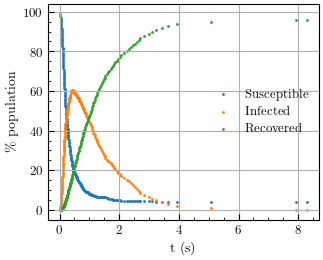

In [30]:
def load_sir(filename: str) -> pd.DataFrame:
    df = pd.read_csv(filename, sep=r'\s+', header=None, comment='#',
                    names=['t','idens', 'rdens', 'irate', 'rrate'], 
                    engine='python')
    df['sdens'] = 1 - df['rdens'] - df['idens']
    return df

from matplotlib import axes as mpl_ax



fig, ax = plt.subplots(dpi=100)

def plot_graph(ax: mpl_ax.Axes, df: pd.DataFrame):
    ax.minorticks_on()
    ax.scatter(df['t'], df['sdens'], label='Susceptible', s=1)
    ax.scatter(df['t'], df['idens'], label='Infected', s=1)
    ax.scatter(df['t'], df['rdens'], label='Recovered', s=1)
    ax.set_xlabel('t (s)')
    ax.set_yticks([i*20/100 for i in range(6)])
    ax.set_yticklabels([str(i*20) for i in range(6)])
    ax.set_ylabel(r'\% population')
    ax.grid()
    # NO incluir leyenda aquí
df_SIR = load_sir(expected_stats_name)
plot_graph(ax, df_SIR)

# Crear handles personalizados para la leyenda
from matplotlib.lines import Line2D

# legend_elements = [
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', 
#            markersize=8, label='Susceptible', markeredgecolor='tab:blue'),
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', 
#            markersize=8, label='Infected', markeredgecolor='tab:orange'),
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green', 
#            markersize=8, label='Recovered', markeredgecolor='tab:green')
# ]

# fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.07), ncol=3)
ax.legend()
# plt.tight_layout(rect=[0, 0.05, 1, 1])  # Ajustar espacio para la leyenda
plt.show()


In [31]:
import pipeline.animation as anim

In [34]:
epidemics_fig_output = f'{epidemic_folder}/disc-boosted'

anim.generate_gif(df, epidemics_fig_output, events, 3, 0.005, start_node, boost=True)


Ventana temporal: 0.00 → 3.00
Total de frames: 601
Simulando evolución de estados...


Simulación:   0%|          | 0/601 [00:00<?, ?it/s]

100%|██████████| 601/601 [01:24<00:00,  7.12it/s]


In [ ]:
x1 = f"{epidemics_fig_output}/sim-%04d.png"
x2 = f"{epidemics_fig_output}/../disc-boosted.gif"
x3 = f"{epidemics_fig_output}/../disc-palette.png"
x4 = f"{epidemics_fig_output}/../disc-boosted.mp4"

! ffmpeg -i {x1} -vf "palettegen" {x3} -y
! ffmpeg -i {x1} -i {x3} -filter_complex "paletteuse" {x2} -y
! ffmpeg -framerate 15 -i {x1} -c:v libx264 -qp 0 -preset veryslow -pix_fmt yuv420p {x4} -y



In [ ]:
a = f"{epidemics_fig_output}/../disc.mp4"
b = f"{epidemics_fig_output}/../disc-boosted.mp4"
c = f"{epidemics_fig_output}/../stacked.mp4"

! ffmpeg -i {a} -i {b} -filter_complex "hstack" {c} -y

#### Graficas de frentes de onda

np.float64(19.490419553592396)

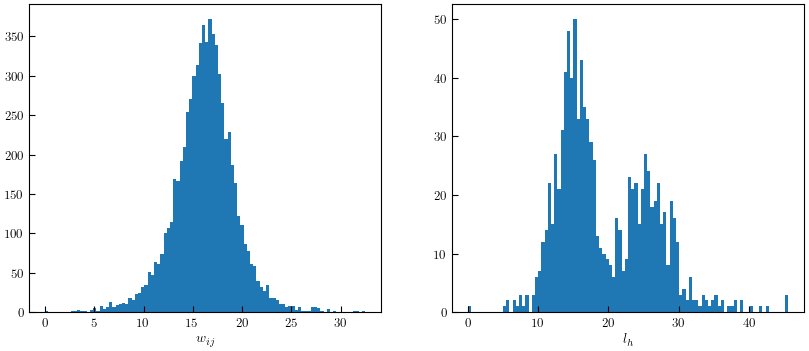

In [ ]:
coords = (
    df.set_index('Vertex')
      [['Disc.Radius', 'Inf.Theta']]
      .to_dict('index')
)

for u, v in G.edges():
    
    r1 = coords[u]['Disc.Radius']
    t1 = coords[u]['Inf.Theta']

    r2 = coords[v]['Disc.Radius']
    t2 = coords[v]['Inf.Theta']

    d = hyp.hyperbolic_distance_og_thetas(r1, t1, r2, t2)

    G[u][v]['weight'] = d

weights = [
    G[u][v]['weight']
    for u,v in G.edges()
]

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4)) 

ax1.hist(weights, bins=100)
ax1.set_xlabel('$w_{ij}$')

path_length = nx.single_source_dijkstra_path_length(
    G,
    start_node,
    weight='weight'
)

hops_dist = nx.single_source_dijkstra_path_length(
    G,
    start_node,
    weight=None
)

ax2.hist(path_length.values(), bins=100)
ax2.set_xlabel('$l_h$')
display(np.average([x for x in path_length.values()]))

plt.show()

In [ ]:


path_length = nx.single_source_dijkstra_path_length(
    G,
    start_node,
    weight='weight'
)

hops_dist = nx.single_source_dijkstra_path_length(
    G,
    start_node,
    weight=None
)

hyp_distances = pd.DataFrame([{'Vertex': k, 'spl': v} for k, v in path_length.items()])
hops_distances = pd.DataFrame([{'Vertex': k, 'spl': v} for k, v in hops_dist.items()])

df_from_start_node = df.set_index('Vertex').join(hyp_distances.set_index('Vertex'))
df_from_start_node_hops = df.set_index('Vertex').join(hops_distances.set_index('Vertex'))

In [18]:
xs = np.linspace(0, 3, 2000)


In [19]:
avg_dists, err_dists= [], []
avg_hyp, err_hyp= [], []
avg_hops, err_hops= [], []

node = df[df['Vertex'] == start_node].iloc[0]
r0, theta0 = node['Disc.Radius'], node['Inf.Theta']
snap = None
for t in tqdm(xs):
    snap = anim.get_snapshot(df, events, t, snap)
    infected_verts = snap['infected']
    mask_inf = df_from_start_node.index.isin(infected_verts)
    infected_nodes = df_from_start_node[mask_inf]
    dists = infected_nodes['spl']
    avg_dists.append(np.average(dists))
    err_dists.append(np.std(dists))
    infected_nodes_hops = df_from_start_node_hops[mask_inf]
    hops = infected_nodes_hops['spl']
    avg_hops.append(np.average(hops))
    err_hops.append(np.std(hops))
    hyp_dist = hyp.hyperbolic_distance_og_thetas(r0, theta0, infected_nodes['Disc.Radius'], infected_nodes['Inf.Theta'])
    avg_hyp.append(np.average(hyp_dist))
    err_hyp.append(np.std(hyp_dist))


  0%|          | 0/2000 [00:00<?, ?it/s]/home/adria/miniconda3/envs/epidemics-tfg/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:576: RuntimeWarning: Mean of empty slice
  avg = a.mean(axis, **keepdims_kw)
/home/adria/miniconda3/envs/epidemics-tfg/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/adria/miniconda3/envs/epidemics-tfg/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:576: RuntimeWarning: Mean of empty slice
  avg = a.mean(axis, **keepdims_kw)
/home/adria/miniconda3/envs/epidemics-tfg/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 2000/2000 [00:04<00:00, 413.71it/s]


164+/-5
-2.7+/-0.5


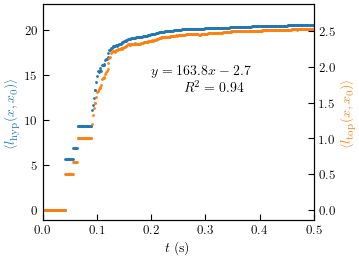

In [ ]:

fig, ax = plt.subplots(dpi=100)
ax.errorbar(xs, avg_hyp, fmt='o', markersize=1, elinewidth=0.1, label='Distances')
ax.set_ylabel(r'$\langle l_ \text{hyp}(x, x_0) \rangle$', color='tab:blue')
ax.set_xlabel('$t$ (s)')
ax2 = ax.twinx()

ax2.scatter(xs, avg_hops, s=1, color='tab:orange')
ax2.set_ylabel(r'$\langle l_\text{top}(x, x_0) \rangle$', color='tab:orange')

data = pd.DataFrame({'xs': xs, 'ys': avg_hyp})

mask = (data['ys'] > 0) & (data['ys'] < 18)
data_masked = data[mask]

coefs, errores, r2, cov_mat = ajuste_polinomial_con_estadisticas_v2(data_masked['xs'], data_masked['ys'], grado=1)
fit = np.poly1d(coefs[::-1])
m = un.ufloat(coefs[1], errores[1])
b = un.ufloat(coefs[0], errores[0])
rcoefs = np.round(coefs, 1)
xs_fit = np.linspace(-100, 600, 1000)
ys_fit = fit(xs_fit)

# ax.plot(xs_fit, ys_fit, '--',  c=plt.cm.tab20.colors[1], linewidth=1)
ax.set_xlim(0, 0.5)
# ax.set_ylim(0, 22)
# ax2.set_ylim(0, 2.6)

ax.annotate(fr'$y = {rcoefs[1]} x {'+' if rcoefs[0] > 0 else '-'} {abs(rcoefs[0])}$', (0.2, 15))
ax.annotate(fr'$R^2 = {np.around(r2, 2)}$', (0.26, 13.2))
print(m)
print(b)
plt.show()

#### Comparació diferents nodes inicials

In [26]:
deg = G.degree()


maxdeg, mindeg = max(deg, key=lambda x: x[1])[1], min(deg, key=lambda x: x[1])[1]
deg_space = np.round(np.linspace(mindeg, maxdeg, 50)[1:-1])
deg_space

sort = sorted(G.degree(), key=lambda x:x[1])
deg_i = 0
# selected = []
# for i in range(len(sort)):
#     k, deg = sort[i]
#     if (deg > deg_space[deg_i]):
#         selected.append(sort[i])
#         deg_i += 1
#         if (deg_i >= len(deg_space)):
#             break
# coords = (
#     df.set_index('Vertex')
#     [['Disc.Radius', 'Inf.Theta']]
#     .to_dict('index')
# )

hyp_distances = {}
Gk = {}
for u, v in G.edges():
    
    r1 = coords[u]['Disc.Radius']
    t1 = coords[u]['Inf.Theta']

    r2 = coords[v]['Disc.Radius']
    t2 = coords[v]['Inf.Theta']

    d = hyp.hyperbolic_distance_og_thetas(r1, t1, r2, t2)

    G[u][v]['dist'] = d

In [11]:
events_sn = {}
targeted_epidemic_folder = f'{working_folder}/targeted-epidemics'

output_batch_file = f"{targeted_epidemic_folder}/batch_targeted_sir.txt"

seed_base = 42075
seeds = 5
i_rate = 1
r_rate = 1
limit_time=1E10
model_type=2 # sir
c='-1x10^-1'
weight_file = f'{edges_file}_weight_{c}'
weighted=True
n=0


with open(output_batch_file, "w") as f:
    f.write("# infection_rate  recovery_rate  seed  limit_time  model_type start_node\n")
    for v in df['Vertex']:
        for s in range(seeds):
        # Escribir línea con 5 valores (start_node opcional omitido)
            f.write(f"{i_rate:.6f} {r_rate:.6f} {seed_base+s} {limit_time:.1f} {model_type} {v}\n")
            n = n+1

print(f"Archivo batch generado: {output_batch_file} con {n} simulaciones.")

Archivo batch generado: ./pipeline-output/out-n1000-g=2.1-b=2.1-k=20/targeted-epidemics/batch_targeted_sir.txt con 4990 simulaciones.


In [ ]:
! ./tools/epidemics -b {output_batch_file} -o {targeted_epidemic_folder} -ev -w {weight_file}

In [19]:
deg = G.degree()
events_sn = {}
seed_base = 42075
seeds = 5
for n, k in tqdm(deg):
    for s in range(seeds):
        i_rate = 1
        r_rate = 1
        model='SIR'
        c='-1x10^-1'
        weight_file = f'{edges_file}_weight_{c}'
        weighted=True
        events_file = f'{targeted_epidemic_folder}/{data.build_events_filename(edges_file, weighted, model, i_rate, r_rate, seed_base+s, int(n))}'
        events_sn[(n, s)] = data.read_events_data(events_file)

100%|██████████| 998/998 [00:10<00:00, 95.98it/s] 


In [ ]:
import numpy as np
from tqdm import tqdm
import pipeline.animation as anim

# ------------------------------------------------------------
# 1. Preprocesamiento: posiciones de los nodos
# ------------------------------------------------------------
vertices = df['Vertex'].values
num_nodes = len(vertices)
vertex_to_idx = {v: i for i, v in enumerate(vertices)}
radii = df['Disc.Radius'].values
thetas = df['Inf.Theta'].values

# ------------------------------------------------------------
# 3. Precalcular matriz de distancias hiperbólicas (N x N)
#    Solo si N es razonable (ej. < 5000). Si no, habrá que
#    calcular distancias sobre la marcha pero evitando recalcular snapshots.
# ------------------------------------------------------------
print("Precalculando matriz de distancias hiperbólicas...")
# Función vectorizada que calcula distancias entre dos conjuntos de puntos
# (puedes adaptar tu hyp.hyperbolic_distance_og_thetas para que trabaje con broadcasting)
def hyperbolic_distance_matrix(r1, theta1, r2, theta2):
    # Implementación típica de distancia hiperbólica en el disco de Poincaré
    # d = arcosh(cosh(r1)*cosh(r2) - sinh(r1)*sinh(r2)*cos(theta1 - theta2))
    # Devuelve matriz de tamaño (len(r1), len(r2))
    cosh_r1 = np.cosh(r1)
    cosh_r2 = np.cosh(r2)
    sinh_r1 = np.sinh(r1)
    sinh_r2 = np.sinh(r2)
    delta_theta = np.abs(theta1[:, None] - theta2[None, :])
    cos_delta = np.cos(delta_theta)
    arg = cosh_r1[:, None] * cosh_r2[None, :] - sinh_r1[:, None] * sinh_r2[None, :] * cos_delta
    # Evitar NaN por errores de redondeo
    arg = np.clip(arg, 1.0, None)   # fuerza valores menores a 1 a ser exactamente 1
    return np.arccosh(arg)  
D = hyperbolic_distance_matrix(radii, thetas, radii, thetas)  # D[i,j] = distancia entre nodo i y nodo j


In [73]:
# 3. Tiempos
xs = np.linspace(0, 2, 1000)

# 4. Diccionario para almacenar resultados por nodo
avg_hyps = {}
err_hyps = {}
avg_hyps_maxs = {}

# 5. Bucle principal sobre nodos (cada nodo como punto de partida)
for n, k in tqdm(G.degree(), desc="Procesando nodos"):
    idx = vertex_to_idx[n]          # índice en la matriz D
    avg_over_t = []
    std_over_t = []
    max_over_t = []
    
    # Para cada semilla (son 5, todas con el mismo nodo inicial n)
    # Vamos a almacenar el último snapshot por semilla para reutilizarlo
    last_snap_by_seed = [None] * seeds
    
    for t in xs:
        dist_means = []
        dist_stds = []
        dist_maxs = []
        
        for s in range(seeds):
            # Cargar eventos de esta semilla y nodo (ya debería estar en events_sn)
            events = events_sn[(n, s)]
            if (len(events) == 3):
                continue
            # Obtener snapshot en el tiempo t (pasa el último snapshot para acelerar)
            snap = anim.get_snapshot(df, events, t, last_snap_by_seed[s])
            last_snap_by_seed[s] = snap   # guardar para la próxima iteración en t
            infected_verts = snap['infected']
            # Convertir vértices a índices
            infected_idxs = np.array([vertex_to_idx[v] for v in infected_verts if v in vertex_to_idx])
            
            if len(infected_idxs) == 0:
                dist_means.append(0.0)
                dist_stds.append(0.0)
                dist_maxs.append(0.0)
            else:
                dists = D[idx, infected_idxs]   # ¡vectorizado gracias a la matriz!
                dist_means.append(np.mean(dists))
                dist_stds.append(np.std(dists))
                dist_maxs.append(np.max(dists))
        
        # Promediar sobre las semillas
        avg_over_t.append(np.mean(dist_means) if len(dist_means) > 0 else np.nan)
        std_over_t.append(np.mean(dist_stds) if len(dist_stds) > 0 else np.nan)
        max_over_t.append(np.mean(dist_maxs) if len(dist_maxs) > 0 else np.nan)
    
    avg_hyps[n] = avg_over_t
    err_hyps[n] = std_over_t
    avg_hyps_maxs[n] = max_over_t

Procesando nodos: 100%|██████████| 998/998 [24:01<00:00,  1.44s/it]


/tmp/ipykernel_38755/2177114469.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(xs, avg_hyps[n], s=1, label=fr'$k_\star = {k}$', c=plt.cm.tab20.colors[2*i+1])


k=13: L=33.11+/-0.10, t0=0.014+/-0.007, v=5.86+/-0.25


RuntimeError: Optimal parameters not found: The maximum number of function evaluations is exceeded.

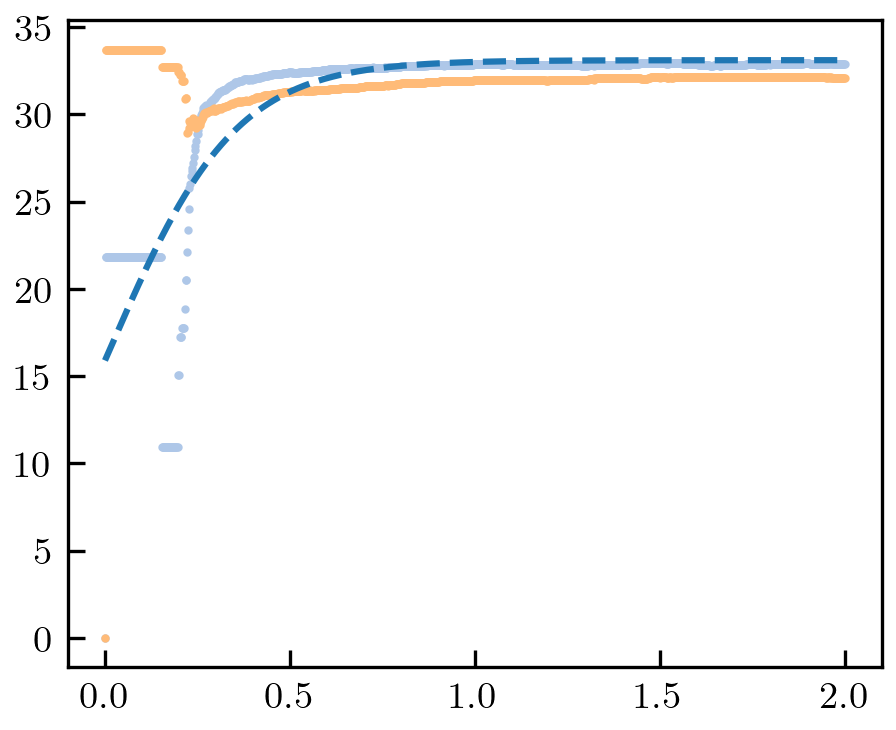

In [47]:
from scipy.optimize import curve_fit
import uncertainties as un
def sigmoid(x, L , x0, k):
    y = L / (1 + np.exp(-k*(x-x0)))
    return (y)

fig, ax = plt.subplots(dpi=300)

curvs = []

for i,(n, k) in enumerate(selected):
    ax.scatter(xs, avg_hyps[n], s=1, label=fr'$k_\star = {k}$', c=plt.cm.tab20.colors[2*i+1])
    # ax.hlines([avg_hyp_total[n]], 0, 5, plt.cm.tab20.colors[i*2+1], '--', linewidth=2)
    p0 = [max(avg_hyps[n]), np.median(xs),1] # this is an mandatory initial guess
    popt, pcov = curve_fit(sigmoid, xs, avg_hyps[n],p0, method='dogbox')
    perr = np.sqrt(np.diag(pcov))
    y_fit = sigmoid(xs, *popt)
    print(f'k={k}: L={un.ufloat(popt[0], perr[0])}, t0={un.ufloat(popt[1], perr[1])}, v={un.ufloat(popt[2], perr[2])}')
    ax.plot(xs, y_fit, "--")
    curvs.append(un.ufloat(popt[2], perr[2]))

ax.set_ylabel(r'$\langle d_\text{hyp}(x, x_\star) \rangle$')
ax.set_xlabel('$t$ (s)')
ax.set_xlim(0,1)
ax.legend()
plt.show()

In [74]:
max(avg_hyps['60'])

np.float64(40.07595606127344)

[np.float64(0.0),
 np.float64(0.08835960065848382),
 np.float64(0.08835960065848382),
 np.float64(0.08835960065848382),
 np.float64(0.08835960065848382),
 np.float64(0.08835960065848382),
 np.float64(0.08835960065848382),
 np.float64(3.1807888366885364),
 np.float64(4.188805282241891),
 np.float64(7.855266133962978),
 np.float64(8.047006711587056),
 np.float64(8.309439177136793),
 np.float64(10.650095961136085),
 np.float64(12.429769969877757),
 np.float64(13.533043890925729),
 np.float64(13.533043890925729),
 np.float64(13.98120078199984),
 np.float64(14.17537866688051),
 np.float64(15.499111891838691),
 np.float64(15.631058548087097),
 np.float64(15.781061232545767),
 np.float64(16.176643627582646),
 np.float64(16.505488670469752),
 np.float64(16.58116569921702),
 np.float64(16.766153328309443),
 np.float64(16.871052188469015),
 np.float64(16.923806422826715),
 np.float64(16.95734807195542),
 np.float64(19.84776947300088),
 np.float64(19.964798019086203),
 np.float64(19.9319571956428

In [89]:
from scipy.optimize import curve_fit
import uncertainties as un
def sigmoid(x, L , x0, k):
    y = L / (1 + np.exp(-k*(x-x0)))
    return (y)

df_deg = pd.DataFrame([{'Vertex':v, 'Degree':k} for v, k in G.degree()])
vels = []
err_vels = []
for k in tqdm(sorted(set(df_deg['Degree'].astype(int)))):
    vel = []
    for n in df_deg[df_deg['Degree'] == k]['Vertex']:
        p0 = [max(avg_hyps[n]), np.median(xs),1] # this is an mandatory initial guess
        popt, pcov = curve_fit(sigmoid, xs, avg_hyps[n], p0, method='dogbox', maxfev=10000)
        vel.append(popt[2])
    vels.append(np.mean(vel))
    err_vels.append(np.std(vel))

  0%|          | 0/78 [00:00<?, ?it/s]

100%|██████████| 78/78 [00:03<00:00, 20.91it/s] 


In [79]:
vels

[np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float6

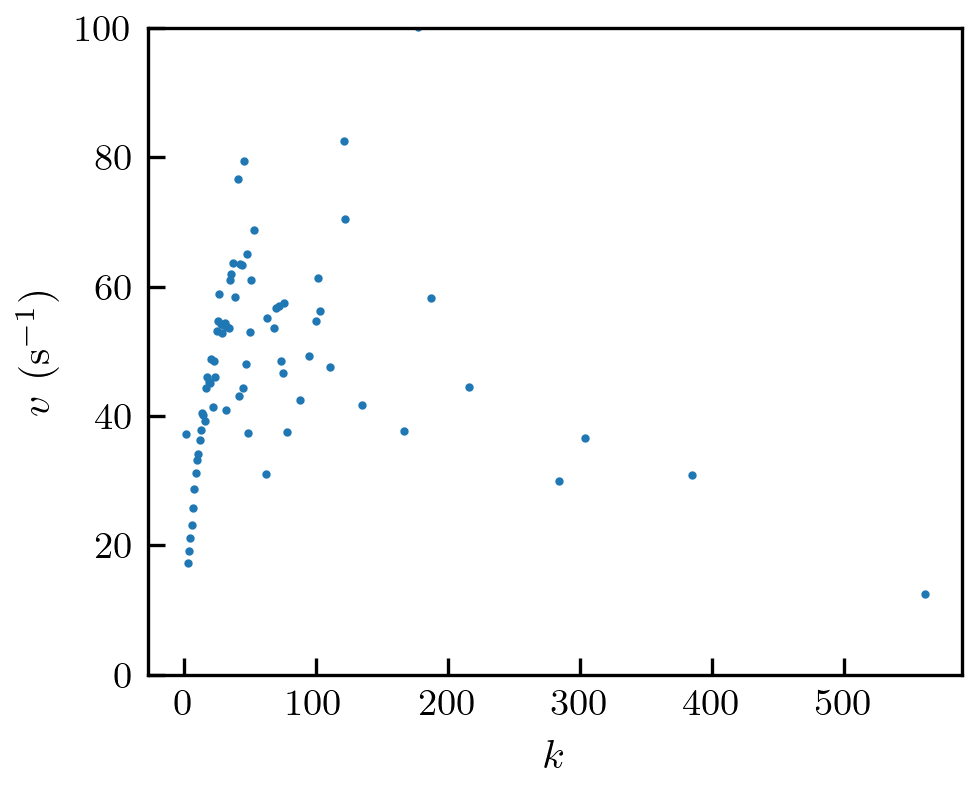

In [99]:
fig, ax = plt.subplots(dpi=300)

ax.errorbar(sorted(set(df_deg['Degree'].astype(int))), vels, fmt='o', markersize=1, elinewidth=0.5)
ax.set_xlabel('$k$')
ax.set_ylabel(r'$v$ (\unit{\per\second})')
ax.set_ylim(0, 100)
plt.show()


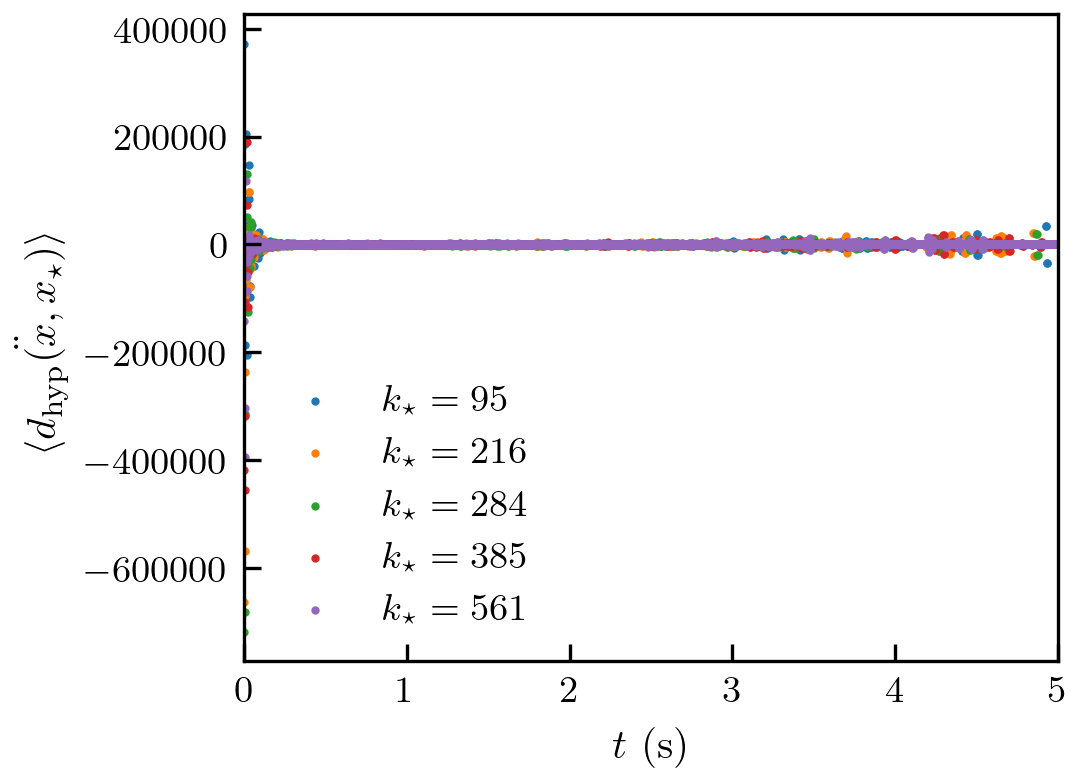

In [26]:
fig, ax = plt.subplots(dpi=300)

for n, k in selected:
    dddt = np.gradient(avg_hyps[n], xs)
    d2ddt2 = np.gradient(dddt, xs)
    ax.scatter(xs, d2ddt2, s=1, label=fr'$k_\star = {k}$')

ax.set_ylabel(r'$\ddot{\langle d_\text{hyp}(x, x_\star) \rangle}$')
ax.set_xlabel('$t$ (s)')
ax.set_xlim(0., 5)
ax.legend()
plt.show()